<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Data_Preparation/Data_Preparation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# -*- coding: utf-8 -*-
"""
==============================================================================
CRISP-DM FASE 3: DATA PREPARATION (VERSIÓN ADAPTADA A ESTRUCTURA REAL)
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 2 de 2 - Preparación Avanzada de Datos
==============================================================================
"""

# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y CARGA DE LIBRERÍAS
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from scipy import sparse

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("CRISP-DM FASE 3: DATA PREPARATION")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 3: DATA PREPARATION
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-16 00:47:02


In [56]:

# ==============================================================================
# 2. FUNCIONES AUXILIARES
# ==============================================================================

def buscar_columna(df, palabras_clave, verbose=False):
    """Busca una columna ignorando mayúsculas y espacios"""
    cols_normalizados = {col.upper().strip(): col for col in df.columns}
    palabras_upper = [p.upper().strip() for p in palabras_clave]

    for col_upper, col_original in cols_normalizados.items():
        if any(p in col_upper for p in palabras_upper):
            if verbose:
                print(f"   ✓ Encontrada: '{col_original}'")
            return col_original

    if verbose:
        print(f"   ✗ No encontrada: {palabras_clave}")
    return None

def encontrar_columnas_multiplas(df, palabras_clave):
    """Encuentra todas las columnas que contengan las palabras clave"""
    cols_normalizados = {col.upper().strip(): col for col in df.columns}
    palabras_upper = [p.upper().strip() for p in palabras_clave]

    resultados = []
    for col_upper, col_original in cols_normalizados.items():
        if any(p in col_upper for p in palabras_upper):
            resultados.append(col_original)

    return resultados

In [57]:
# ==============================================================================
# 3. CARGA DE DATOS
# ==============================================================================

ruta = '/content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx'

print("\n📂 Cargando datos desde:", ruta)
datos_filtrados = pd.read_excel(ruta, sheet_name="Datos_filtrados")

print(f"\n✅ Datos cargados exitosamente")
print(f"   - Dataset: {datos_filtrados.shape[0]:,} registros × {datos_filtrados.shape[1]} columnas")

datos_originales = datos_filtrados.copy()


📂 Cargando datos desde: /content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx

✅ Datos cargados exitosamente
   - Dataset: 56,473 registros × 28 columnas


In [58]:
# ==============================================================================
# 4. DIAGNÓSTICO INICIAL
# ==============================================================================

print("\n" + "=" * 80)
print("📊 DIAGNÓSTICO INICIAL - ESTRUCTURA DE DATOS")
print("=" * 80)

print(f"\nColumnas disponibles ({len(datos_filtrados.columns)}):")
for i, col in enumerate(datos_filtrados.columns, 1):
    tipo = datos_filtrados[col].dtype
    faltantes = datos_filtrados[col].isna().sum()
    pct_faltante = (faltantes / len(datos_filtrados)) * 100
    print(f"   {i:2d}. {col:45s} | {str(tipo):15s} | {pct_faltante:5.1f}% faltante")



📊 DIAGNÓSTICO INICIAL - ESTRUCTURA DE DATOS

Columnas disponibles (28):
    1. Base_Origen                                   | object          |   0.0% faltante
    2. Fecha_intervencion                            | datetime64[ns]  |   0.0% faltante
    3. Localidad_fic                                 | object          |   0.0% faltante
    4. Red_fic                                       | object          |   0.0% faltante
    5. TIPO INTERVENCIÓN                             | object          |  14.3% faltante
    6. NACIONALIDAD                                  | object          |  19.8% faltante
    7. SEXO                                          | object          |  19.8% faltante
    8. ESTADO CIVIL                                  | object          |   0.0% faltante
    9. FECHA DE NACIMIENTO                           | datetime64[ns]  |  19.8% faltante
   10. EDAD                                          | float64         |  43.8% faltante
   11. CURSO DE VIDA                 

In [59]:
# ==============================================================================
# 5. FEATURE ENGINEERING TEMPORAL (ANTES DE EXCLUIR FECHAS)
# ==============================================================================

print("\n" + "=" * 80)
print("📅 FEATURE ENGINEERING: VARIABLE TEMPORAL")
print("=" * 80)

# Clasificación por tipo
cat_cols = datos_filtrados.select_dtypes(include='object').columns.tolist()
num_cols = datos_filtrados.select_dtypes(include=['int64', 'float64']).columns.tolist()
date_cols = datos_filtrados.select_dtypes(include=['datetime64']).columns.tolist()

# Crear ANTIGUEDAD_DIAS ANTES de excluir fechas
fecha_interv_col = buscar_columna(datos_filtrados, ['FECHA', 'INTERVENCION', 'INGRESO'], verbose=True)

if fecha_interv_col:
    try:
        fecha_ref = pd.Timestamp.now()
        datos_filtrados['ANTIGUEDAD_DIAS'] = (fecha_ref - datos_filtrados[fecha_interv_col]).dt.days
        datos_filtrados['ANTIGUEDAD_DIAS'].fillna(0, inplace=True)
        datos_filtrados['ANTIGUEDAD_DIAS'] = datos_filtrados['ANTIGUEDAD_DIAS'].clip(lower=0)

        print(f"✅ ANTIGUEDAD_DIAS creada")
        print(f"   - Rango: [{datos_filtrados['ANTIGUEDAD_DIAS'].min():.0f}, {datos_filtrados['ANTIGUEDAD_DIAS'].max():.0f}] días")
        print(f"   - Promedio: {datos_filtrados['ANTIGUEDAD_DIAS'].mean():.0f} días (~{datos_filtrados['ANTIGUEDAD_DIAS'].mean()/365:.1f} años)")

        # Crear variable categórica para interpretación (pero no se usa en clustering)
        datos_filtrados['FASE_INTERVENCION'] = pd.cut(
            datos_filtrados['ANTIGUEDAD_DIAS'],
            bins=[0, 180, 720, float('inf')],
            labels=['Reciente (0-6m)', 'Seguimiento (6m-2a)', 'Prolongada (>2a)'],
            include_lowest=True
        )
        print(f"   - Distribución por fase:")
        print(datos_filtrados['FASE_INTERVENCION'].value_counts())

    except Exception as e:
        print(f"⚠️  Error creando ANTIGUEDAD_DIAS: {e}")
else:
    print("⚠️  No se encontró columna de fecha - ANTIGUEDAD_DIAS NO se creará")

# Separar columnas numéricas reales de fechas
num_cols_reales = [col for col in num_cols if 'FECHA' not in col.upper()]

print(f"\n📌 Clasificación DESPUÉS de Feature Engineering Temporal:")
print(f"   • Categóricas: {len(cat_cols)}")
print(f"   • Numéricas: {len(num_cols_reales)} (+ ANTIGUEDAD_DIAS si se creó)")
print(f"   • Fechas (SERÁN EXCLUIDAS): {len(date_cols)}")

# IMPORTANTE: Excluir columnas de fecha del análisis
print(f"\n⚠️  EXCLUYENDO columnas de fecha del clustering:")
for col in date_cols:
    print(f"   - {col}")

# ESTRATEGIA 1: Excluir TODAS las columnas de fecha (no se usan en clustering)
print(f"\n📌 EXCLUYENDO todas las columnas de fecha...")
vars_a_excluir = date_cols.copy()
print(f"   Total de fechas excluidas: {len(vars_a_excluir)}")

# ESTRATEGIA 2: Excluir FASE_INTERVENCION (variable categórica solo para interpretación)
if 'FASE_INTERVENCION' in datos_filtrados.columns:
    vars_a_excluir.append('FASE_INTERVENCION')
    print(f"   ✗ FASE_INTERVENCION: excluida (solo para interpretación)")

# ESTRATEGIA 3: Excluir variables con >50% faltantes
umbral_faltantes = 50
print(f"\n📌 APLICANDO CRITERIO: Excluir variables con >{umbral_faltantes}% faltantes")

for col in datos_filtrados.columns:
    if col not in vars_a_excluir:  # No contar fechas que ya se excluyeron
        pct_faltante = (datos_filtrados[col].isna().sum() / len(datos_filtrados)) * 100
        if pct_faltante > umbral_faltantes:
            vars_a_excluir.append(col)
            print(f"   ✗ {col}: {pct_faltante:.1f}% faltante → EXCLUIDA")

# Actualizar listas: excluir variables de fecha y FASE_INTERVENCION
variables_a_usar = [col for col in datos_filtrados.columns if col not in vars_a_excluir]
cat_cols = [col for col in cat_cols if col not in vars_a_excluir]
num_cols_reales = [col for col in num_cols_reales if col not in vars_a_excluir]

# IMPORTANTE: Si ANTIGUEDAD_DIAS se creó, asegurarse que esté en num_cols_reales
if 'ANTIGUEDAD_DIAS' in datos_filtrados.columns and 'ANTIGUEDAD_DIAS' not in num_cols_reales:
    num_cols_reales.append('ANTIGUEDAD_DIAS')

date_cols = []  # Todas las fechas ya fueron excluidas

# Filtrar datos a variables de interés
datos_filtrados = datos_filtrados[variables_a_usar].copy()

print(f"\n✅ Variables RETENIDAS para análisis: {len(variables_a_usar)}")
print(f"   • Categóricas: {len(cat_cols)}")
print(f"   • Numéricas: {len(num_cols_reales)}")
print(f"   • Fechas EXCLUIDAS: {len(date_cols) + len([c for c in vars_a_excluir if 'FECHA' in c.upper()])}")
print(f"\n   Variables incluidas:")
for col in variables_a_usar:
    print(f"      ✓ {col}")



📅 FEATURE ENGINEERING: VARIABLE TEMPORAL
   ✓ Encontrada: 'Fecha_intervencion'
✅ ANTIGUEDAD_DIAS creada
   - Rango: [199, 1678] días
   - Promedio: 955 días (~2.6 años)
   - Distribución por fase:
FASE_INTERVENCION
Prolongada (>2a)       38062
Seguimiento (6m-2a)    18411
Reciente (0-6m)            0
Name: count, dtype: int64

📌 Clasificación DESPUÉS de Feature Engineering Temporal:
   • Categóricas: 22
   • Numéricas: 2 (+ ANTIGUEDAD_DIAS si se creó)
   • Fechas (SERÁN EXCLUIDAS): 4

⚠️  EXCLUYENDO columnas de fecha del clustering:
   - Fecha_intervencion
   - FECHA DE NACIMIENTO
   - FECHA - SEGUIMIENTO CIERRE
   - FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE

📌 EXCLUYENDO todas las columnas de fecha...
   Total de fechas excluidas: 4
   ✗ FASE_INTERVENCION: excluida (solo para interpretación)

📌 APLICANDO CRITERIO: Excluir variables con >50% faltantes
   ✗ INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO: 59.6% faltante → EXCL

In [60]:

# ==============================================================================
# 6. IMPUTACIÓN DE VALORES FALTANTES
# ==============================================================================

print("\n" + "=" * 80)
print("🧹 IMPUTACIÓN DE VALORES FALTANTES")
print("=" * 80)

# 6.1 Imputación de EDAD
edad_col = buscar_columna(datos_filtrados, ['EDAD'])
sexo_col = buscar_columna(datos_filtrados, ['SEXO', 'GÉNERO'])

if edad_col:
    faltantes_edad = datos_filtrados[edad_col].isna().sum()
    if faltantes_edad > 0:
        if sexo_col:
            print(f"\n✅ Imputando {edad_col} con mediana estratificada por {sexo_col}")
            for sexo in datos_filtrados[sexo_col].dropna().unique():
                mask = datos_filtrados[sexo_col] == sexo
                mediana_edad = datos_filtrados.loc[mask, edad_col].median()
                if pd.notna(mediana_edad):
                    datos_filtrados.loc[mask & datos_filtrados[edad_col].isna(), edad_col] = mediana_edad
                    print(f"   - {sexo}: {mediana_edad:.1f} años")
        else:
            mediana_edad = datos_filtrados[edad_col].median()
            datos_filtrados[edad_col].fillna(mediana_edad, inplace=True)
            print(f"✅ {edad_col} imputada con mediana: {mediana_edad:.1f} años")
    else:
        print(f"✅ {edad_col}: 100% completa")

# 6.2 Imputación de variables numéricas restantes
num_cols_knn = [col for col in num_cols_reales if datos_filtrados[col].isna().sum() > 0]

if num_cols_knn:
    print(f"\n📄 Procesando {len(num_cols_knn)} variables numéricas con faltantes:")
    for col in num_cols_knn:
        faltantes = datos_filtrados[col].isna().sum()
        pct = (faltantes / len(datos_filtrados)) * 100
        print(f"   - {col}: {faltantes:,} ({pct:.1f}%)")

    # Usar SimpleImputer con mediana (más robusto que KNN con muchos faltantes)
    try:
        imputer = SimpleImputer(strategy='median')
        datos_filtrados[num_cols_knn] = imputer.fit_transform(datos_filtrados[num_cols_knn])
        print("   ✅ Imputación por mediana completada")
    except Exception as e:
        print(f"   ⚠️  Error: {e}")

# 6.3 Imputación de variables categóricas
cat_cols_faltantes = [col for col in cat_cols if datos_filtrados[col].isna().sum() > 0]

if cat_cols_faltantes:
    print(f"\n📄 Procesando {len(cat_cols_faltantes)} variables categóricas con faltantes:")
    for col in cat_cols_faltantes:
        faltantes = datos_filtrados[col].isna().sum()
        pct = (faltantes / len(datos_filtrados)) * 100
        print(f"   - {col}: {faltantes:,} ({pct:.1f}%)")

    for col in cat_cols_faltantes:
        datos_filtrados[col].fillna("No_reporta", inplace=True)
    print("   ✅ Imputación completada con 'No_reporta'")

print(f"\n✅ ESTADO FINAL: {datos_filtrados.isna().sum().sum()} valores faltantes totales")



🧹 IMPUTACIÓN DE VALORES FALTANTES

✅ Imputando EDAD con mediana estratificada por SEXO
   - 1- Hombre: 9.0 años
   - 2- Mujer: 9.0 años
   - 3- Intersexual: 12.0 años

📄 Procesando 2 variables numéricas con faltantes:
   - EDAD: 11,173 (19.8%)
   - UPZ/UPR: 9,652 (17.1%)
   ✅ Imputación por mediana completada

📄 Procesando 14 variables categóricas con faltantes:
   - TIPO INTERVENCIÓN: 8,090 (14.3%)
   - NACIONALIDAD: 11,173 (19.8%)
   - SEXO: 11,173 (19.8%)
   - CURSO DE VIDA: 24,728 (43.8%)
   - OCUPACIÓN: 20,276 (35.9%)
   - VÍNCULO CON EL JEFE DE HOGAR: 20,106 (35.6%)
   - ZONA: 9,618 (17.0%)
   - BARRIO PRIORIZADO: 28,140 (49.8%)
   - MANZANA DEL CUIDADO: 28,141 (49.8%)
   - ESTRATO: 28,141 (49.8%)
   - AFILIACIÓN AL SGSSS.1: 11,171 (19.8%)
   - ESTRATO SOCIOECONÓMICO: 11,432 (20.2%)
   - ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?: 15,439 (27.3%)
   - NNA DESVINCULADO DE LA ACTIVIDAD LABORAL: 12,144 (21.5%)
   ✅ Imputación completada con 'No_reporta'

✅ ESTADO FINAL: 0 valores 

In [61]:

# ==============================================================================
# 7. FEATURE ENGINEERING
# ==============================================================================

print("\n" + "=" * 80)
print("🧪 FEATURE ENGINEERING - CREACIÓN DE VARIABLES")
print("=" * 80)

nuevas_variables = []

# Variable 1: EDAD_GRUPO
if edad_col and edad_col in datos_filtrados.columns:
    try:
        datos_filtrados['EDAD_GRUPO'] = pd.cut(
            datos_filtrados[edad_col],
            bins=[0, 5, 10, 14, 18, 100],
            labels=[1, 2, 3, 4, 5],
            include_lowest=True
        ).astype(float)
        nuevas_variables.append('EDAD_GRUPO')
        print(f"✅ EDAD_GRUPO creada (5 grupos etarios)")
        print(f"   Distribución:\n{datos_filtrados['EDAD_GRUPO'].value_counts().sort_index()}")
    except Exception as e:
        print(f"⚠️  No se pudo crear EDAD_GRUPO: {e}")

# Variable 2: LOCALIDAD_DENSIDAD
localidad_col = buscar_columna(datos_filtrados, ['LOCALIDAD', 'UPZ'])
if localidad_col:
    try:
        localidad_counts = datos_filtrados[localidad_col].value_counts()
        datos_filtrados['LOCALIDAD_DENSIDAD'] = datos_filtrados[localidad_col].map(localidad_counts)
        nuevas_variables.append('LOCALIDAD_DENSIDAD')
        print(f"✅ LOCALIDAD_DENSIDAD creada")
        print(f"   Rango: [{datos_filtrados['LOCALIDAD_DENSIDAD'].min():.0f}, {datos_filtrados['LOCALIDAD_DENSIDAD'].max():.0f}]")
    except Exception as e:
        print(f"⚠️  No se pudo crear LOCALIDAD_DENSIDAD: {e}")

# Variable 3: ANTIGÜEDAD EN PROGRAMA
fecha_interv_col = buscar_columna(datos_filtrados, ['FECHA_INTERVENCION', 'FECHA DE INGRESO'])
if fecha_interv_col:
    try:
        datos_filtrados[fecha_interv_col] = pd.to_datetime(datos_filtrados[fecha_interv_col], errors='coerce')
        fecha_ref = pd.Timestamp.now()
        datos_filtrados['ANTIGUEDAD_DIAS'] = (fecha_ref - datos_filtrados[fecha_interv_col]).dt.days
        datos_filtrados['ANTIGUEDAD_DIAS'].fillna(0, inplace=True)
        datos_filtrados['ANTIGUEDAD_DIAS'] = datos_filtrados['ANTIGUEDAD_DIAS'].clip(lower=0)
        nuevas_variables.append('ANTIGUEDAD_DIAS')
        print(f"✅ ANTIGUEDAD_DIAS creada")
        print(f"   Rango: [{datos_filtrados['ANTIGUEDAD_DIAS'].min():.0f}, {datos_filtrados['ANTIGUEDAD_DIAS'].max():.0f}] días")
    except Exception as e:
        print(f"⚠️  No se pudo crear ANTIGUEDAD_DIAS: {e}")

# Actualizar lista de numéricas
num_cols_reales.extend([col for col in nuevas_variables if col in datos_filtrados.columns])
print(f"\n✅ Total variables numéricas: {len(num_cols_reales)}")


🧪 FEATURE ENGINEERING - CREACIÓN DE VARIABLES
✅ EDAD_GRUPO creada (5 grupos etarios)
   Distribución:
EDAD_GRUPO
1.0     8407
2.0    35474
3.0     8147
4.0     4445
Name: count, dtype: int64
✅ LOCALIDAD_DENSIDAD creada
   Rango: [1, 7957]

✅ Total variables numéricas: 5


In [62]:
# ==============================================================================
# 8. SELECCIÓN DE VARIABLES PARA CLUSTERING
# ==============================================================================

print("\n" + "=" * 80)
print("🎯 SELECCIÓN FINAL DE VARIABLES PARA CLUSTERING")
print("=" * 80)

print(f"\nVariables NUMÉRICAS seleccionadas ({len(num_cols_reales)}):")
for col in num_cols_reales:
    print(f"   ✓ {col}")

print(f"\nVariables CATEGÓRICAS seleccionadas ({len(cat_cols)}):")
for col in cat_cols:
    print(f"   ✓ {col}")



🎯 SELECCIÓN FINAL DE VARIABLES PARA CLUSTERING

Variables NUMÉRICAS seleccionadas (5):
   ✓ EDAD
   ✓ UPZ/UPR
   ✓ ANTIGUEDAD_DIAS
   ✓ EDAD_GRUPO
   ✓ LOCALIDAD_DENSIDAD

Variables CATEGÓRICAS seleccionadas (21):
   ✓ Base_Origen
   ✓ Localidad_fic
   ✓ Red_fic
   ✓ TIPO INTERVENCIÓN
   ✓ NACIONALIDAD
   ✓ SEXO
   ✓ ESTADO CIVIL
   ✓ CURSO DE VIDA
   ✓ ETNIA
   ✓ POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN
   ✓ OCUPACIÓN
   ✓ CATEGORÍAS DE LA DISCAPACIDAD
   ✓ VÍNCULO CON EL JEFE DE HOGAR
   ✓ ZONA
   ✓ BARRIO PRIORIZADO
   ✓ MANZANA DEL CUIDADO
   ✓ ESTRATO
   ✓ AFILIACIÓN AL SGSSS.1
   ✓ ESTRATO SOCIOECONÓMICO
   ✓ ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?
   ✓ NNA DESVINCULADO DE LA ACTIVIDAD LABORAL


In [63]:
# ==============================================================================
# 9. CODIFICACIÓN CATEGÓRICA (LABEL ENCODING - COMPATIBLE)
# ==============================================================================

print("\n" + "=" * 80)
print("🔤 CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 80)

if len(cat_cols) > 0:
    print(f"\n📄 Label Encoding para {len(cat_cols)} variables categóricas...")

    # Convertir a string
    datos_filtrados[cat_cols] = datos_filtrados[cat_cols].astype(str)

    from sklearn.preprocessing import LabelEncoder
    encoded_df = pd.DataFrame(index=datos_filtrados.index)

    try:
        for col in cat_cols:
            le = LabelEncoder()
            encoded_df[f'{col}_LE'] = le.fit_transform(datos_filtrados[col].fillna('Missing'))

        print(f"✅ Label Encoding completado:")
        print(f"   • Variables codificadas: {encoded_df.shape[1]}")

    except Exception as e:
        print(f"❌ Error: {e}")
        encoded_df = pd.DataFrame(index=datos_filtrados.index)

else:
    print("⚠️  No hay variables categóricas")
    encoded_df = pd.DataFrame(index=datos_filtrados.index)


🔤 CODIFICACIÓN DE VARIABLES CATEGÓRICAS

📄 Label Encoding para 21 variables categóricas...
✅ Label Encoding completado:
   • Variables codificadas: 21


In [64]:
# ==============================================================================
# 10. NORMALIZACIÓN DE VARIABLES NUMÉRICAS
# ==============================================================================

print("\n" + "=" * 80)
print("📊 NORMALIZACIÓN DE VARIABLES NUMÉRICAS")
print("=" * 80)

if len(num_cols_reales) > 0:
    # Verificación final de NaN
    nans_finales = datos_filtrados[num_cols_reales].isna().sum().sum()
    if nans_finales > 0:
        print(f"⚠️  Aún hay {nans_finales} NaN - rellenando con mediana")
        imputer_final = SimpleImputer(strategy='median')
        datos_filtrados[num_cols_reales] = imputer_final.fit_transform(datos_filtrados[num_cols_reales])

    print(f"\n📄 StandardScaler para {len(num_cols_reales)} variables...")

    scaler = StandardScaler()
    scaled_num = scaler.fit_transform(datos_filtrados[num_cols_reales])
    scaled_df = pd.DataFrame(scaled_num, columns=num_cols_reales, index=datos_filtrados.index)

    print("✅ Estandarización completada (media=0, std=1)")
    print("\nVerificación (primeras 5 variables):")
    print(scaled_df[num_cols_reales[:5]].describe().loc[['mean', 'std']].round(3))
else:
    print("⚠️  No hay variables numéricas")
    scaled_df = pd.DataFrame(index=datos_filtrados.index)


📊 NORMALIZACIÓN DE VARIABLES NUMÉRICAS

📄 StandardScaler para 5 variables...
✅ Estandarización completada (media=0, std=1)

Verificación (primeras 5 variables):
      EDAD  UPZ/UPR  ANTIGUEDAD_DIAS  EDAD_GRUPO  LOCALIDAD_DENSIDAD
mean  -0.0     -0.0              0.0        -0.0                -0.0
std    1.0      1.0              1.0         1.0                 1.0


In [65]:
# ==============================================================================
# 11. UNIÓN FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("🔗 CONSTRUCCIÓN DEL DATASET FINAL")
print("=" * 80)

print(f"\nDEBUG - Shapes antes de concatenar:")
print(f"   scaled_df: {scaled_df.shape}")
print(f"   encoded_df: {encoded_df.shape}")

dfs_a_concat = []
if not scaled_df.empty:
    dfs_a_concat.append(scaled_df)
    print(f"   ✓ scaled_df agregado")
if not encoded_df.empty:
    dfs_a_concat.append(encoded_df)
    print(f"   ✓ encoded_df agregado")

if dfs_a_concat:
    datos_preparados = pd.concat(dfs_a_concat, axis=1)
    print(f"\n✅ Dataset final:")
    print(f"   • Dimensiones: {datos_preparados.shape[0]:,} × {datos_preparados.shape[1]:,}")
    print(f"   • Numéricas escaladas: {len(num_cols_reales)}")
    print(f"   • Categóricas codificadas: {encoded_df.shape[1]:,}")
    print(f"   • Memoria: {datos_preparados.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
else:
    print("❌ CRÍTICO: No hay datos para preparar")
    datos_preparados = pd.DataFrame()




🔗 CONSTRUCCIÓN DEL DATASET FINAL

DEBUG - Shapes antes de concatenar:
   scaled_df: (56473, 5)
   encoded_df: (56473, 21)
   ✓ scaled_df agregado
   ✓ encoded_df agregado

✅ Dataset final:
   • Dimensiones: 56,473 × 26
   • Numéricas escaladas: 5
   • Categóricas codificadas: 21
   • Memoria: 11.20 MB


In [66]:

# ==============================================================================
# 12. VALIDACIONES
# ==============================================================================

print("\n" + "=" * 80)
print("✅ VALIDACIONES DE CALIDAD")
print("=" * 80)

if not datos_preparados.empty:
    infinitos = np.isinf(datos_preparados.select_dtypes(include=[np.number])).sum().sum()
    nans = datos_preparados.isna().sum().sum()
    varianzas = datos_preparados.var()
    vars_cero = (varianzas == 0).sum()
    duplicados = datos_preparados.duplicated().sum()

    print(f"\n1️⃣ Valores infinitos: {infinitos}")
    print(f"2️⃣ Valores NaN: {nans}")
    print(f"3️⃣ Variables con varianza cero: {vars_cero}")
    print(f"4️⃣ Registros duplicados: {duplicados:,} ({(duplicados/len(datos_preparados)*100):.2f}%)")



✅ VALIDACIONES DE CALIDAD

1️⃣ Valores infinitos: 0
2️⃣ Valores NaN: 0
3️⃣ Variables con varianza cero: 0
4️⃣ Registros duplicados: 10,821 (19.16%)



🔍 ANÁLISIS PCA EXPLORATORIO

✅ Componentes para 95% varianza: 4


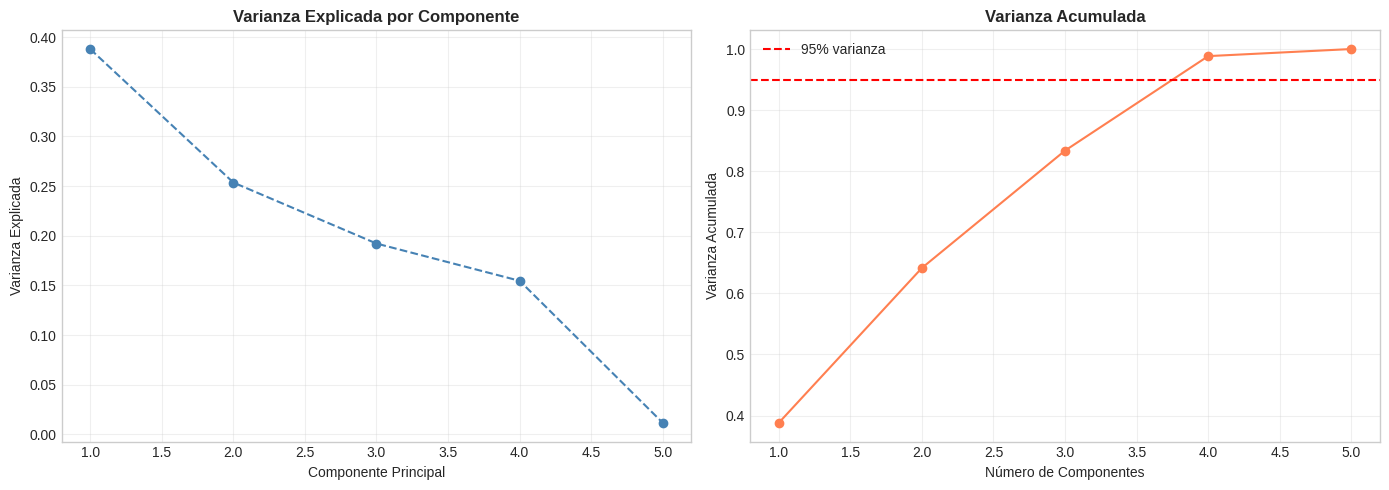

In [67]:
# ==============================================================================
# 13. ANÁLISIS PCA
# ==============================================================================

print("\n" + "=" * 80)
print("🔍 ANÁLISIS PCA EXPLORATORIO")
print("=" * 80)

if len(scaled_df.columns) > 1:
    pca_test = PCA()
    pca_test.fit(scaled_df)

    n_componentes_95 = np.argmax(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95) + 1
    print(f"\n✅ Componentes para 95% varianza: {n_componentes_95}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, min(21, len(pca_test.explained_variance_ratio_) + 1)),
                 pca_test.explained_variance_ratio_[:20],
                 marker='o', linestyle='--', color='steelblue')
    axes[0].set_title('Varianza Explicada por Componente', fontweight='bold')
    axes[0].set_xlabel('Componente Principal')
    axes[0].set_ylabel('Varianza Explicada')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(1, min(21, len(pca_test.explained_variance_ratio_) + 1)),
                 np.cumsum(pca_test.explained_variance_ratio_)[:20],
                 marker='o', linestyle='-', color='coral')
    axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
    axes[1].set_title('Varianza Acumulada', fontweight='bold')
    axes[1].set_xlabel('Número de Componentes')
    axes[1].set_ylabel('Varianza Acumulada')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    n_componentes_95 = 1
    print("⚠️  Pocas variables para PCA")


In [68]:
# ==============================================================================
# 13. ELIMINACIÓN DE DUPLICADOS
# ==============================================================================

print("\n" + "=" * 80)
print("🗑️  ELIMINACIÓN DE DUPLICADOS")
print("=" * 80)

duplicados_antes = datos_preparados.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados_antes:,} ({duplicados_antes/len(datos_preparados)*100:.2f}%)")

if duplicados_antes > 0:
    datos_preparados = datos_preparados.drop_duplicates(keep='first').reset_index(drop=True)
    duplicados_despues = datos_preparados.duplicated().sum()
    print(f"Duplicados eliminados: {duplicados_antes:,}")
    print(f"\n✅ Dataset final: {datos_preparados.shape[0]:,} registros únicos")
    print(f"Dimensiones finales: {datos_preparados.shape}")
else:
    print("✅ No hay duplicados")


🗑️  ELIMINACIÓN DE DUPLICADOS

Registros duplicados detectados: 10,821 (19.16%)
Duplicados eliminados: 10,821

✅ Dataset final: 45,652 registros únicos
Dimensiones finales: (45652, 26)


In [69]:
# ==============================================================================
# 14. EXPORTACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

if not os.path.exists(ruta_salida):
    os.makedirs(ruta_salida)

try:
    # Guardar dataset completo
    csv_completo = ruta_salida + "datos_preparados_completo.csv.gz"
    datos_preparados.to_csv(csv_completo, index=False, compression='gzip')
    print(f"\n✅ Dataset completo: {csv_completo}")

    # Guardar solo numéricas
    csv_numerico = ruta_salida + "datos_preparados_numericos.csv"
    scaled_df.to_csv(csv_numerico, index=False)
    print(f"✅ Dataset numérico: {csv_numerico}")

    # Metadatos
    metadata = {
        'fecha': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'registros': datos_preparados.shape[0],
        'variables_totales': datos_preparados.shape[1],
        'variables_numericas': len(num_cols_reales),
        'variables_categoricas_codificadas': encoded_df.shape[1],
        'componentes_95pct': n_componentes_95
    }

    pd.DataFrame([metadata]).to_csv(ruta_salida + "metadata_preparacion.csv", index=False)
    print(f"✅ Metadatos guardados")

    # Guardar scaler y encoder
    with open(ruta_salida + 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    with open(ruta_salida + 'encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)
    print(f"✅ Objetos guardados (scaler.pkl, encoder.pkl)")

except Exception as e:
    print(f"❌ Error: {e}")



💾 EXPORTACIÓN DE RESULTADOS

✅ Dataset completo: /content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_completo.csv.gz
✅ Dataset numérico: /content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_numericos.csv
✅ Metadatos guardados
✅ Objetos guardados (scaler.pkl, encoder.pkl)


In [70]:
# ==============================================================================
# 15. RESUMEN FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("🎯 RESUMEN FINAL - FASE DATA PREPARATION")
print("=" * 80)

print(f"""
✅ PROCESO COMPLETADO

DIMENSIONES FINALES:
   • Registros: {datos_preparados.shape[0]:,}
   • Variables: {datos_preparados.shape[1]:,}
   • Numéricas: {len(num_cols_reales)}
   • Categóricas codificadas: {encoded_df.shape[1]:,}

TRANSFORMACIONES:
   ✓ Exclusión de variables >50% faltantes
   ✓ Imputación de valores faltantes
   ✓ {len(nuevas_variables)} nuevas variables generadas
   ✓ Codificación One-Hot
   ✓ Estandarización

CALIDAD:
   ✓ NaN finales: {datos_preparados.isna().sum().sum()}
   ✓ Dataset listo para clustering

PRÓXIMO PASO: Modeling (K-Means, DBSCAN, Jerárquico)
""")

print("=" * 80)
print("✓ LISTO PARA FASE 4: MODELING")
print("=" * 80)



🎯 RESUMEN FINAL - FASE DATA PREPARATION

✅ PROCESO COMPLETADO

DIMENSIONES FINALES:
   • Registros: 45,652
   • Variables: 26
   • Numéricas: 5
   • Categóricas codificadas: 21

TRANSFORMACIONES:
   ✓ Exclusión de variables >50% faltantes
   ✓ Imputación de valores faltantes
   ✓ 2 nuevas variables generadas
   ✓ Codificación One-Hot
   ✓ Estandarización

CALIDAD:
   ✓ NaN finales: 0
   ✓ Dataset listo para clustering

PRÓXIMO PASO: Modeling (K-Means, DBSCAN, Jerárquico)

✓ LISTO PARA FASE 4: MODELING
